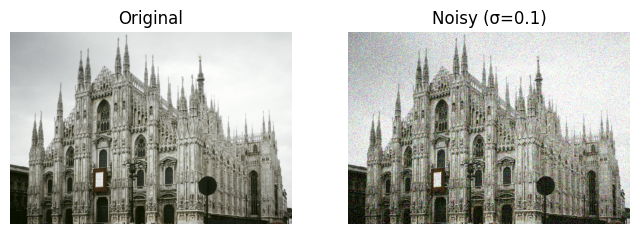

In [ ]:
# Colab cell 1 — load image and add noise
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

img=Image.open('image.jpg').convert('RGB')
img=np.array(img).astype(np.float32)/255.0  # float image in [0,1]

# adding Gaussian noise
sigma_noise=0.1
noisy_image=img+np.random.normal(0,sigma_noise,img.shape).astype(np.float32)
noisy_image=np.clip(noisy_image,0.0,1.0)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1);plt.imshow(img);plt.title('Original');plt.axis('off')
plt.subplot(1,2,2);plt.imshow(noisy_image);plt.title('Noisy (σ={})'.format(sigma_noise));plt.axis('off')
plt.show()


#Bilateral Filtering Implementation

PSNR noisy: 20.616 dB
PSNR filtered: 25.182 dB


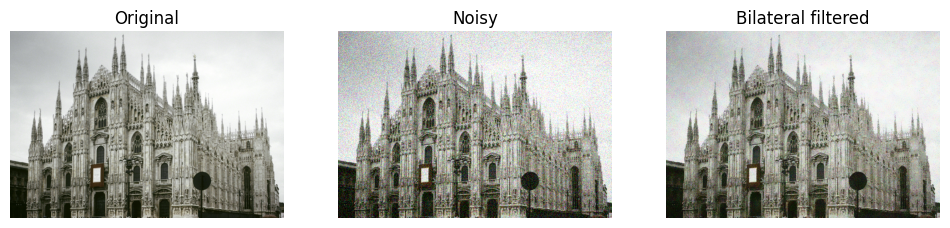

In [ ]:
import math
def psnr(a, b):
    #calculates peak-signal to noise ratio= 20log10. (max/rootMSE)
    mse=np.mean((a-b)**2)
    return 20*math.log10(1.0/math.sqrt(mse)) if mse>0 else 100.0

def bilateral_filter(img, kernel_radius=3, sigma_s=3.0, sigma_r=0.1):
    H,W,C=img.shape
    out=np.zeros_like(img)
    kr = kernel_radius
    # precompute spatial gaussian
    ax = np.arange(-kr, kr+1)
    xx, yy = np.meshgrid(ax, ax)
    spatial = np.exp(-(xx**2 + yy**2) / (2 * (sigma_s**2)))

    # pad image
    pad = kr
    padded = np.pad(img, ((pad,pad),(pad,pad),(0,0)), mode='reflect')

    for y in range(H):
        for x in range(W):
            yc, xc = y + pad, x + pad
            window = padded[yc-kr:yc+kr+1, xc-kr:xc+kr+1, :]  # (k,k,C)
            center = padded[yc, xc, :][None, None, :]          # (1,1,C)
            # compute color (range) gaussian using L2 color distance
            diff = window - center
            color_dist2 = np.sum(diff * diff, axis=2)  # sum over channels
            range_w = np.exp(- color_dist2 / (2 * (sigma_r**2)))
            weights = spatial * range_w  # elementwise
            Wsum = np.sum(weights)
            # weighted sum over channels
            val = np.sum(window * weights[:, :, None], axis=(0,1)) / (Wsum + 1e-12)
            out[y, x, :] = val
    return out

# Parameters (tweak if needed)
kernel_radius = 5    # window radius, e.g., 3..7
sigma_s = 5.0        # spatial sigma
sigma_r = 0.12       # range sigma (intensity); ~same scale as image [0,1]

# run bilateral filter on noisy image
filtered = bilateral_filter(noisy_image, kernel_radius=kernel_radius, sigma_s=sigma_s, sigma_r=sigma_r)

# print PSNRs and show results
print("PSNR noisy:", round(psnr(img, noisy_image), 3), "dB")
print("PSNR filtered:", round(psnr(img, filtered), 3), "dB")

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title('Original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(noisy_image); plt.title('Noisy'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(np.clip(filtered,0,1)); plt.title('Bilateral filtered'); plt.axis('off')
plt.show()


#Guided Filtering Implementation

PSNR noisy vs original: 26.311 dB
PSNR filtered vs original: 28.189 dB


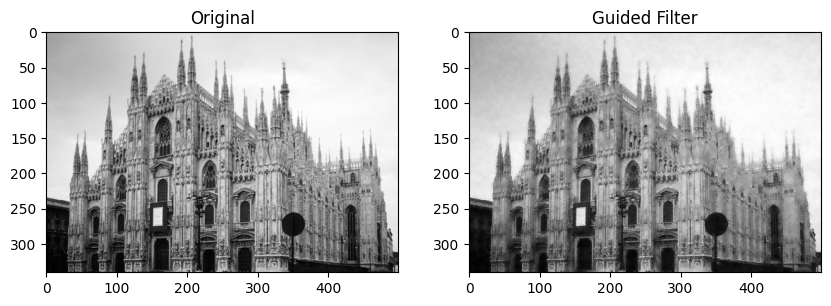

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def psnr(a, b):
    mse = np.mean((a - b) ** 2)
    return 20 * math.log10(1.0 / math.sqrt(mse)) if mse > 0 else 100.0
#I Original Image
#Ig guided image
def guidedfilter(I, Ig, w=3, eps=1e-3):
    I = I.astype(np.float32)
    Ig = Ig.astype(np.float32)
    h, W = I.shape
    padding = w

    #giving padding for filter
    Ipadding = cv2.copyMakeBorder(I, padding, padding, padding, padding, cv2.BORDER_REFLECT)
    Igpadding = cv2.copyMakeBorder(Ig, padding, padding, padding, padding, cv2.BORDER_REFLECT)
    output = np.zeros_like(I)
    for i in range(h):
        for j in range(W):

            s = i + padding
            t = j + padding

            windowIg = Igpadding[s-w:s+w+1, t-w:t+w+1]
            windowI = Ipadding[s-w:s+w+1, t-w:t+w+1]

            # mean and variance of guidance image
            muk = np.mean(windowIg)
            vark = np.var(windowIg)

            # neighbouring weight compute
            differences = Igpadding[s, t] - muk
            differencet = windowIg - muk
            wst = 1 + (differences * differencet) / (vark + eps)

            # Normalize weights
            wst = wst / np.sum(wst)

            # Filtered value
            output[i, j] = np.sum(wst * windowI)
    return np.clip(output, 0, 1)
img = cv2.imread('image.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) / 255.0
noisy = np.clip(gray + np.random.normal(0, 0.05, gray.shape), 0, 1)
guided = guidedfilter(noisy, noisy, w=3, eps=0.01)
print("PSNR noisy vs original:", round(psnr(gray, noisy), 3), "dB")
print("PSNR filtered vs original:", round(psnr(gray, guided), 3), "dB")
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(guided, cmap='gray')
plt.title("Guided Filter")

plt.show()


#Geodesic Filtering Implementation

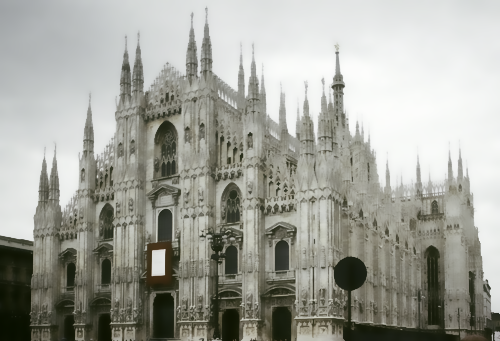

In [8]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def geodesic_filter(img, guidance, radius=5, sigma_color=30, sigma_space=3):
    # Convert to float for computation
    img = img.astype(np.float32)
    guidance = guidance.astype(np.float32)

    # Pad for boundary
    pad = radius
    padded = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REFLECT)
    guide_padded = cv2.copyMakeBorder(guidance, pad, pad, pad, pad, cv2.BORDER_REFLECT)

    h, w, _ = img.shape
    filtered = np.zeros_like(img)

    # Precompute spatial Gaussian
    y, x = np.mgrid[-radius:radius+1, -radius:radius+1]
    spatial_weight = np.exp(-(x**2 + y**2) / (2 * sigma_space**2))

    # Iterate over pixels
    for i in range(h):
        for j in range(w):
            # Extract local patch
            patch = padded[i:i+2*radius+1, j:j+2*radius+1]
            guide_patch = guide_padded[i:i+2*radius+1, j:j+2*radius+1]
            center = guide_padded[i+radius, j+radius]

            # Compute color distance (Euclidean)
            color_diff = guide_patch - center
            color_dist = np.sqrt(np.sum(color_diff ** 2, axis=2))

            # Geodesic approximation: combine color + spatial distance
            color_weight = np.exp(-(color_dist**2) / (2 * sigma_color**2))
            weight = spatial_weight * color_weight

            # Normalize weights
            weight_sum = np.sum(weight)
            if weight_sum != 0:
                weight = weight / weight_sum

            # Weighted sum for each color channel
            for c in range(3):
                filtered[i, j, c] = np.sum(patch[:, :, c] * weight)

    return np.clip(filtered, 0, 255).astype(np.uint8)


# ---- Usage Example ----
img = cv2.imread("image.jpg")
filtered = geodesic_filter(img, img, radius=5, sigma_color=50, sigma_space=3)
cv2_imshow(filtered)


#Propagation Filter Implementation

rows: 100%|██████████| 341/341 [02:36<00:00,  2.18it/s]


PSNR noisy: 20.616 dB
PSNR filtered: 22.525 dB


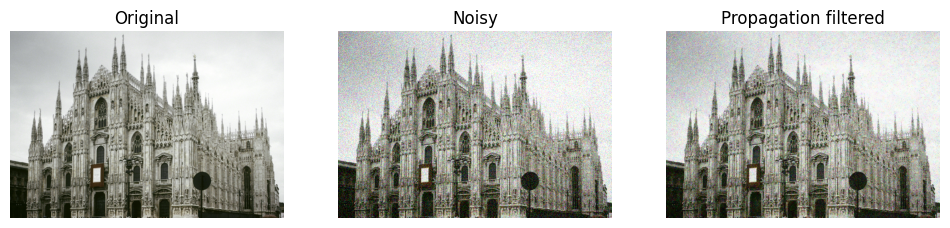

In [ ]:
import math
from tqdm import tqdm

def psnr(a, b):
    mse = np.mean((a - b) ** 2)
    return 20 * math.log10(1.0 / math.sqrt(mse)) if mse > 0 else 100.0

def propagation_filter(img, w=3, sigma=0.1):
    H, W, C = img.shape
    out = np.zeros_like(img)
    pad = w
    padded = np.pad(img, ((pad,pad),(pad,pad),(0,0)), mode='reflect')

    # predefine Gaussian for photometric relation
    def G(delta):  # Gaussian based on intensity difference
        return np.exp(- (delta**2) / (2 * sigma**2))

    # Propagation in 4 directions (simplified 2D path pattern)
    for y in tqdm(range(H), desc="rows"):
        for x in range(W):
            yc, xc = y + pad, x + pad
            center = padded[yc, xc, :]
            ws_sum = np.zeros((2*w+1, 2*w+1))
            num_sum = np.zeros(3)

            # iterate through neighborhood
            for dy in range(-w, w+1):
                for dx in range(-w, w+1):
                    ny, nx = yc + dy, xc + dx
                    neighbor = padded[ny, nx, :]

                    # propagate relationship: along path, weight reduces
                    diff_center = np.linalg.norm(center - neighbor)
                    # adjacent-pixel factor: between neighbor and its previous step
                    prev = padded[ny - np.sign(dy), nx - np.sign(dx), :]
                    diff_adj = np.linalg.norm(prev - neighbor)

                    # combine both as in eq (7) using Gaussian D and R
                    D = G(diff_adj)
                    R = G(diff_center)
                    weight = D * R
                    ws_sum[dy+w, dx+w] = weight
                    num_sum += neighbor * weight

            Z = np.sum(ws_sum)
            out[y, x, :] = num_sum / (Z + 1e-8)
    return out

# Run propagation filter
filtered = propagation_filter(noisy_image, w=3, sigma=0.1)

# Display results
print("PSNR noisy:", round(psnr(img, noisy_image), 3), "dB")
print("PSNR filtered:", round(psnr(img, filtered), 3), "dB")

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title('Original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(noisy_image); plt.title('Noisy'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(np.clip(filtered,0,1)); plt.title('Propagation filtered'); plt.axis('off')
plt.show()


#Experiments

#Image Denoising

#Image Smoothening

In [ ]:
img = cv2.imread('image_smoothening.jpg')
filtered = bilateral_filter(img, kernel_radius=kernel_radius, sigma_s=sigma_s, sigma_r=sigma_r)

# print PSNRs and show results
print("PSNR noisy:", round(psnr(img, img), 3), "dB")
print("PSNR filtered:", round(psnr(img, filtered), 3), "dB")


/tmp/ipython-input-3012655477.py:28: RuntimeWarning: overflow encountered in exp
  range_w = np.exp(- color_dist2 / (2 * (sigma_r**2)))
/tmp/ipython-input-3012655477.py:32: RuntimeWarning: invalid value encountered in divide
  val = np.sum(window * weights[:, :, None], axis=(0,1)) / (Wsum + 1e-12)
/tmp/ipython-input-3012655477.py:33: RuntimeWarning: invalid value encountered in cast
  out[y, x, :] = val
/tmp/ipython-input-3012655477.py:32: RuntimeWarning: invalid value encountered in multiply
  val = np.sum(window * weights[:, :, None], axis=(0,1)) / (Wsum + 1e-12)


PSNR noisy: 100.0 dB
PSNR filtered: -20.369 dB


#Flash/No Flash Denoising

#Image Fusion

GEODESIC FILTER